# BatchNorm

In [34]:
import torch 
import random
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import Image
%matplotlib inline 
random.seed(42)

## 1. Model Definition

In [2]:
words = open('data/names.txt', 'r').read().splitlines()

In [3]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
chars = [chr(i) for i in range(ord('a'), ord('z')+1)]
stoi = {s:i+1 for i, s in enumerate(chars)} # map characters to numbers
stoi['.'] = 0 # special character indicating start and end
itos = {i:s for s, i in stoi.items()} # used for visualization

In [5]:
block_size = 3 # context length (number of characters)

def build_dataset(words):
    # build the dataset
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch] # find index
            X.append(context)
            Y.append(ix)
    
            # add the char
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

# split into training and testing sets
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [6]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

## 2. Applying Fixes

Before we continue with the previous network, let's first address some inefficiencies.

### Problem 1: Initial Loss

Essentially, the network starts overconfident and the initial loss is too high. 

With 27 possible characters, a network that knows nothing should assign equal probability to each, which is roughly $\frac{1}{27} \approx 3.7\%$ per character. The theoretical loss at this baseline is:

In [33]:
-np.log(1/27)

np.float64(3.295836866004329)

This is the best possible loss for a random guesser. Training should start near here and improve from it. However, with standard random initialization, the actual inital loss is far higher, often between 15-27. 

The reason is that the output logits come from `h @ w2 + b2`. With `w2` at standard scale (~1, values drawn from a normal distribution), the logits are large and varied - one character might get a logit of +4.2, another -3.1. Softmax (in cross entropy calculation) amplifies these differences exponentially:

$$softmax(x_i) = \frac{exp(x_i)}{sum(exp(x_j))}$$

As such, the highest logit ends up with probability near 1.0, everything else near 0. The network is extremely confident — but in random directions. When the correct character happens to have a near-zero probability, cross entropy loss is: $loss = -log(\sim0)$, which is a very large number. 

#### **Fix 1**:

Scale `w2` by 0.01 so logits start near zero. With all logits near zero, softmax returns approximately uniform probabilities (~1/27 per class), and the initial loss starts near the theoretical 3.29. 

`b2` is set to zero for the same reason,  any non-zero bias shifts some logits and reintroduces overconfidence. Starting both at near-zero gives the network a neutral starting point. From there, every training step is genuine learning rather than damage control.

Initialisation only sets the starting point. Every training step updates w2 via gradient descent.

**Note**: `w2` must be small but not exactly zero. If `w2 = 0`, all neurons in the hidden layer receive identical gradient signals and the network loses the ability to specialize. 

### Problem 2: Saturated `tanh`

The hidden layer `h` computes a pre-activation then passes it through `tanh`.

Remember that `tanh` is an activation function that squashes any input value into the range (-1, 1). Its shape is an S-curve, steep and roughly linear in the middle, but flat at both extremes. When the input is a large positive number, the output is close to 1. When the input is a large negative number, the output is close to -1. These flat regions are called "saturated" zones.

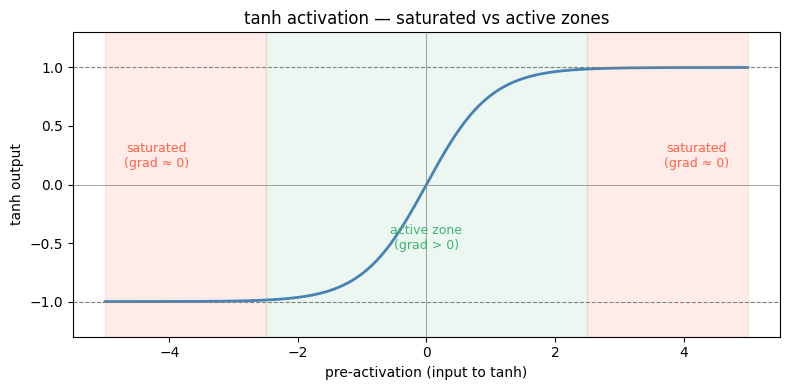

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-5, 5, 1000)
y = np.tanh(x)

sns.lineplot(x=x, y=y, ax=ax, color='steelblue', linewidth=2)

# saturated zones
ax.axvspan(-5, -2.5, alpha=0.12, color='tomato', label='saturated')
ax.axvspan( 2.5,  5, alpha=0.12, color='tomato')

# active zone
ax.axvspan(-2.5, 2.5, alpha=0.10, color='mediumseagreen', label='active')

# reference lines
ax.axhline( 1, color='grey', linewidth=0.8, linestyle='--')
ax.axhline(-1, color='grey', linewidth=0.8, linestyle='--')
ax.axhline( 0, color='grey', linewidth=0.5)
ax.axvline( 0, color='grey', linewidth=0.5)

# labels
ax.text(-4.2, 0.15, 'saturated\n(grad ≈ 0)', color='tomato', fontsize=9, ha='center')
ax.text( 4.2, 0.15, 'saturated\n(grad ≈ 0)', color='tomato', fontsize=9, ha='center')
ax.text( 0,  -0.55, 'active zone\n(grad > 0)', color='mediumseagreen', fontsize=9, ha='center')

ax.set_xlabel('pre-activation (input to tanh)')
ax.set_ylabel('tanh output')
ax.set_title('tanh activation — saturated vs active zones')
ax.set_ylim(-1.3, 1.3)
plt.tight_layout()
plt.show()

In the previous network, the pre-activation going into `tanh` is `h_preact = emb @ w1 + b1`. This is the sum of many multiplied random values. 

With `fan_in = 30` inputs and `w1` initialised at standard scale (~1), each product `w[i] * x[i]` has variance ~1. Adding 30 of them gives total variance of 30, meaning spread (std) of `sqrt(30) ≈ 5.5`.

Most of them land far out in the flat regions of `tanh`, producing outputs very close to -1 or 1. 

**The network has the following structure**:

`C (embeddings) → w1 → b1 → h_preact → tanh → w2 → b2 → loss`

Gradients flow backwards through this. `w2` and `b2` sit after tanh, so their gradients never pass through it, they update normally. But to reach `w1`, `b1`, and the embeddings `C`, the gradient must pass through `tanh`. If `tanh` is saturated for most neurons, those gradients die there.

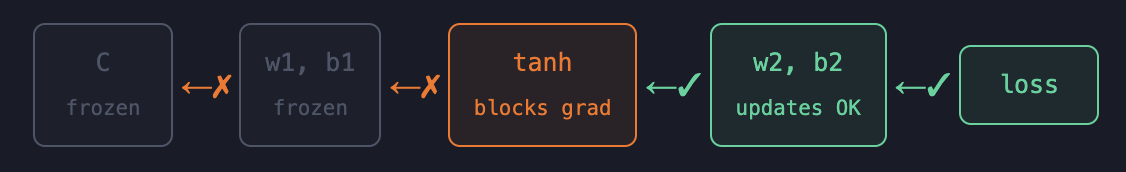

In [44]:
Image('structure.png')

`w1` alone is 30 × 200 = 6,000 parameters, the bulk of the network's capacity. If those are frozen, the hidden layer cannot learn useful representations. `w2` is mapping from a static, never-improving hidden layer, the network collapses to roughly a linear model.

The loss does decrease (`w2` and `b2` are updating), but it quickly plateaus.

#### **Fix 2**:

The problem is that summing fan_in values amplifies variance. The fix is to shrink the weights so the amplification cancels out. 

If each weight has `std = 1/sqrt(fan_in)`, then each product `w[i]*x[i]` has variance `1/fan_in`. 

Summing `fan_in` of them: `variance = fan_in × (1/fan_in) = 1`

Now the output has the same variance as the input. The signal passes through unchanged in scale.

For `tanh`, there is a recommended gain of 5/3, the whole formula (Kaiming Initialization) is:

$$\frac{5}{3} / \sqrt{fan\_in}$$

**Note**: 
- Kiming init applies to any activation function, but the `gain` factor changes depending on which one you use. For example, ReLU has a gain of $\sqrt{2}$. 

- This initialization should apply to every weight matrix in the network that feeds into an activation function. In this network, `w1` is the only one that feeds into `tanh`, so it's the only one that needs it. `w2` feeds directly into the loss (no activation), so it gets treated differently.

#### **Fix 3**: Batch Normalization

idk

## 3. Building the Neural Network

Fixes applied:

In [26]:
n_embd     = 10  # embedding dimension per character
n_hidden   = 200 # neurons in hidden layer
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),            generator=g)
# variance preservation, without scaling, the sum of 30 inputs explodes the spread to ~5.5, saturating tanh and killing gradients. Kaiming init fixes that.
w1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
w2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, w1, b1, w2, b2]
for p in parameters: p.requires_grad_()
print(f"Total parameters: {sum(p.nelement() for p in parameters):,}")

Total parameters: 11,897


## 4. Training the Neural Network

In [27]:
epoch         = 10000
batch_size    = 32
learning_rate = 0.1
lossi         = []

for i in range(epoch):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb    = C[Xb]
    h      = torch.tanh(emb.view(-1, block_size * n_embd) @ w1 + b1)
    logits = h @ w2 + b2
    loss   = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -learning_rate * p.grad

    # logging
    lossi.append(loss.log10().item())
    if i % 1000 == 0:
        print(f"step {i:>6}/{epoch} | loss: {loss.item():.4f}")

step      0/10000 | loss: 3.3179
step   1000/10000 | loss: 2.1438
step   2000/10000 | loss: 2.3596
step   3000/10000 | loss: 2.1125
step   4000/10000 | loss: 2.1116
step   5000/10000 | loss: 2.2234
step   6000/10000 | loss: 2.1057
step   7000/10000 | loss: 2.4183
step   8000/10000 | loss: 1.9589
step   9000/10000 | loss: 2.1460


After the two fixes above, the loss would have decreased from the previous model, the reason being we are now spending more time doing productive training.

In [28]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    emb    = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h      = torch.tanh(embcat @ w1 + b1)
    logits = h @ w2 + b2
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.2444417476654053
val 2.266248941421509


Sample some names from the model: 

In [22]:
for _ in range(10):
    out = []
    context = [0] * block_size

    while True:
        # getting the probabilities
        emb = C[torch.tensor([context])] # embed the current 3 context characters
        h = torch.tanh(emb.view(1, -1) @ w1 + b1) # hidden layer, one row as this is only one example
        logits = h @ w2 + b2 # output layer
        probs = F.softmax(logits, dim=1) # convert to probabilities

        # get the next character
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample randomly from the output probabilities
        context = context[1:] + [ix] # update context
        out.append(ix)

        # stop when we hit end
        if ix == 0:
            break 

    print(''.join(itos[i] for i in out[:-1]))

aadya
jesharelsi
aisleigh
ryvynor
sye
marisa
yaksyncanbren
raviyonn
vephidmiachaiden
maalus
